# 03 — Churn Prediction
**Financial Operations Analytics**

We engineer **CLV** and **RFM-style** features (computed *without* the churn target to
avoid leakage), build a preprocessing pipeline, and benchmark three classifiers —
**Logistic Regression, Random Forest, XGBoost**. We evaluate with ROC/AUC, confusion
matrix and a full classification report, surface the **top-10 churn drivers**, and
export a ranked **at-risk customer list**.

**Target:** test accuracy **> 75%**.

> **Leakage control.** `Churn Score`, `CLTV` and `Churn Reason` are derived from the
> outcome and are *excluded* from the feature set. CLV/RFM features here are rebuilt
> from spend & tenure only.


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "dashboard"} else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.viz import set_style, save_fig
from src.metrics import classification_scores
set_style()

PROC = ROOT / "data" / "processed" / "telco_clean.csv"
AT_RISK_OUT = ROOT / "reports" / "at_risk_customers.csv"
SEG_HELPER_OUT = ROOT / "data" / "processed" / "churn_scored.csv"
RANDOM_STATE = 42

df = pd.read_csv(PROC)
print(f"{df.shape[0]:,} customers | churn rate {df['Churn Value'].mean():.1%}")

7,043 customers | churn rate 30.7%


## 1. Feature engineering (CLV & RFM, leakage-free)
- **AvgMonthlySpend** = Total Charges / tenure
- **CLV_est** = monthly profit × contract-based expected horizon
- **NumAddons** = count of subscribed add-on services
- **RFM-style**: Frequency = tenure, Monetary = Total Charges (both quintile-scored)


In [2]:
feat = df.copy()
feat["AvgMonthlySpend"] = feat["Total Charges"] / feat["Tenure Months"].clip(lower=1)
horizon = np.select(
    [feat["Contract"] == "Two year", feat["Contract"] == "One year"],
    [36.0, 24.0], default=12.0)
feat["CLV_est"] = (feat["MonthlyProfit"].clip(lower=0) * horizon).round(2)

addon_cols = ["Online Security", "Online Backup", "Device Protection",
              "Tech Support", "Streaming TV", "Streaming Movies"]
feat["NumAddons"] = (feat[addon_cols] == "Yes").sum(axis=1)

# RFM-style quintiles from spend & tenure only (no churn signal).
feat["F_Score"] = pd.qcut(feat["Tenure Months"].rank(method="first"), 5, labels=False) + 1
feat["M_Score"] = pd.qcut(feat["Total Charges"].rank(method="first"), 5, labels=False) + 1
feat[["AvgMonthlySpend", "CLV_est", "NumAddons", "F_Score", "M_Score"]].describe().round(2)

,AvgMonthlySpend,CLV_est,NumAddons,F_Score,M_Score
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,59.80,264.63,1.73,3.00,3.00
std,23.21,217.46,1.39,1.41,1.41
min,0.00,0.00,0.00,1.00,1.00
25%,48.64,79.74,0.00,2.00,2.00
50%,65.14,254.04,2.00,3.00,3.00
75%,77.80,381.72,3.00,4.00,4.00
max,122.33,1463.76,6.00,5.00,5.00


In [3]:
# Assemble model matrix. Drop IDs, geo, and any outcome-derived columns.
drop_cols = ["CustomerID", "Count", "Country", "State", "City", "Zip Code",
             "Lat Long", "Latitude", "Longitude", "SignupMonth",
             "Churn Label", "Churn Value", "Churn Score", "CLTV", "Churn Reason"]
y = feat["Churn Value"]
X = feat.drop(columns=drop_cols)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(f"{X.shape[1]} features | {len(cat_cols)} categorical, {len(num_cols)} numeric")

29 features | 16 categorical, 13 numeric


## 2. Train / test split & preprocessing pipeline

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
print(f"Train {X_train.shape} | Test {X_test.shape}")

Train (5282, 29) | Test (1761, 29)


## 3. Train the three classifiers

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, max_depth=10, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=350, max_depth=4, learning_rate=0.05, subsample=0.9,
        colsample_bytree=0.9, eval_metric="logloss", random_state=RANDOM_STATE),
}

fitted, scores, proba = {}, [], {}
for name, est in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    pr = pipe.predict_proba(X_test)[:, 1]
    fitted[name] = pipe
    proba[name] = pr
    scores.append(classification_scores(y_test, pred, pr, name))
results = pd.DataFrame(scores).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7853,0.6866,0.5519,0.6119,0.8268
1,XGBoost,0.7802,0.6624,0.5778,0.6172,0.8195
2,Random Forest,0.7785,0.6829,0.5185,0.5895,0.8190


In [6]:
best_name = results.iloc[0]["Model"]
best = fitted[best_name]
best_acc = results.iloc[0]["Accuracy"]
print(f"Best model: {best_name}  |  test accuracy {best_acc:.1%}")
assert best_acc > 0.75, "Accuracy target (>75%) not met"
print("Accuracy target >75% met.")

Best model: Logistic Regression  |  test accuracy 78.5%
Accuracy target >75% met.


## 4. ROC curves

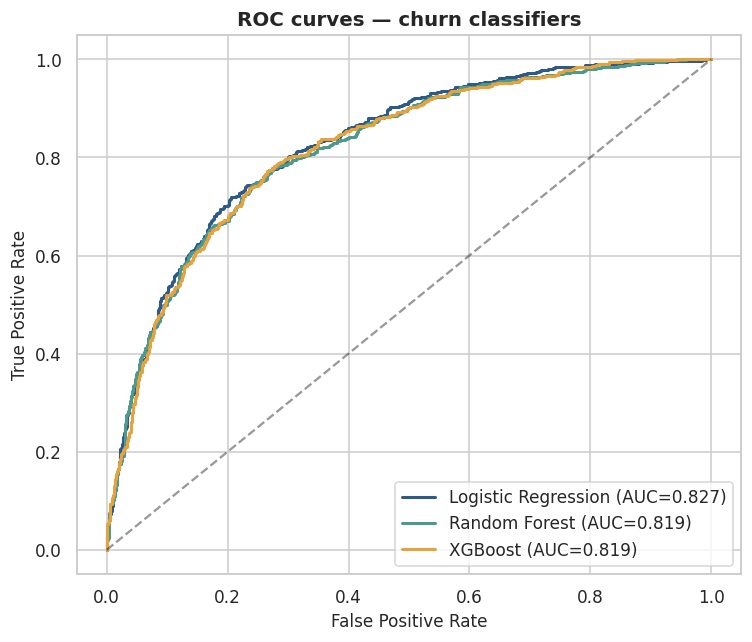

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score
fig, ax = plt.subplots(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(y_test, proba[name]):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves — churn classifiers"); ax.legend(loc="lower right")
plt.tight_layout(); save_fig(fig, "03_roc_curves"); plt.show()

## 5. Confusion matrix & classification report (best model)

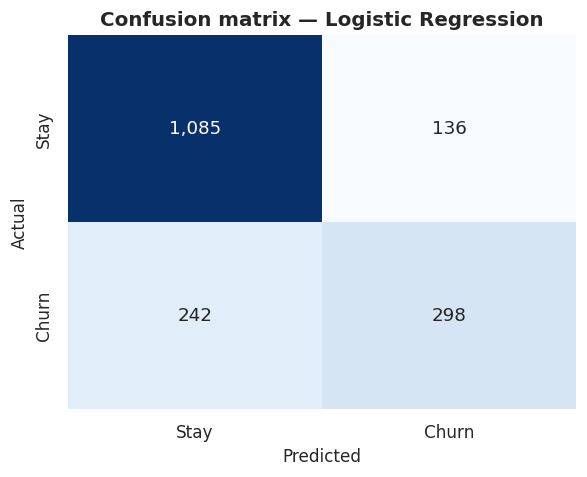

              precision    recall  f1-score   support

        Stay       0.82      0.89      0.85      1221
       Churn       0.69      0.55      0.61       540

    accuracy                           0.79      1761
   macro avg       0.75      0.72      0.73      1761
weighted avg       0.78      0.79      0.78      1761



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
pred_best = best.predict(X_test)
cm = confusion_matrix(y_test, pred_best)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout(); save_fig(fig, "03_confusion_matrix"); plt.show()
print(classification_report(y_test, pred_best, target_names=["Stay", "Churn"]))

## 6. Top-10 churn drivers

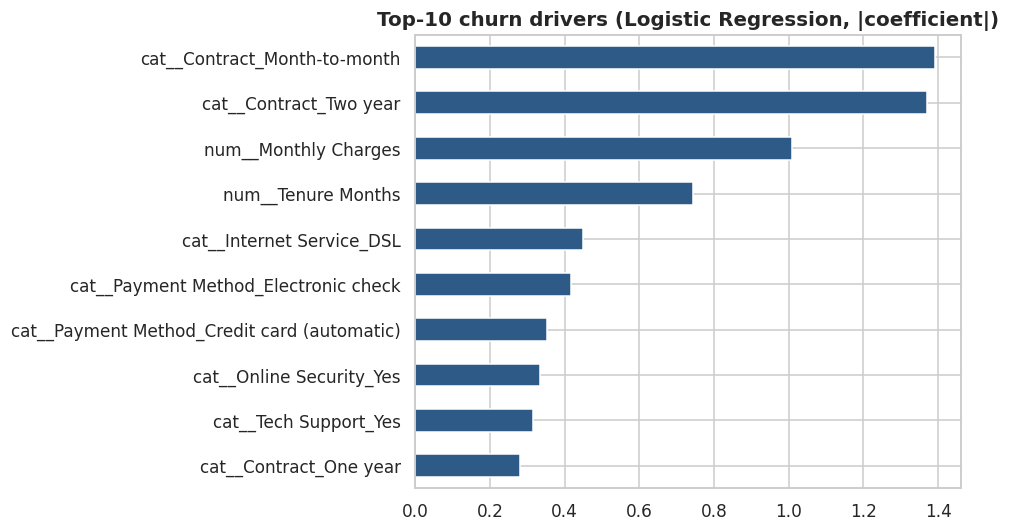

cat__Contract_Month-to-month                   1.3925
cat__Contract_Two year                         1.3692
num__Monthly Charges                           1.0093
num__Tenure Months                             0.7444
cat__Internet Service_DSL                      0.4498
cat__Payment Method_Electronic check           0.4167
cat__Payment Method_Credit card (automatic)    0.3518
cat__Online Security_Yes                       0.3343
cat__Tech Support_Yes                          0.3152
cat__Contract_One year                         0.2805
dtype: float64

In [9]:
feat_names = best.named_steps["prep"].get_feature_names_out()
model_obj = best.named_steps["model"]
if hasattr(model_obj, "feature_importances_"):
    imp = model_obj.feature_importances_
    kind = "importance"
else:
    imp = np.abs(model_obj.coef_[0])
    kind = "|coefficient|"
drivers = (pd.Series(imp, index=feat_names)
           .sort_values(ascending=False).head(10)[::-1])
fig, ax = plt.subplots(figsize=(9, 5))
drivers.plot.barh(ax=ax, color="#2E5A88")
ax.set_title(f"Top-10 churn drivers ({best_name}, {kind})")
plt.tight_layout(); save_fig(fig, "03_top_drivers"); plt.show()
drivers[::-1].round(4)

## 7. At-risk customer list
The fitted model scores every customer; we rank by churn probability and export the
highest-risk **currently-active** customers (with their revenue & CLV at stake).

In [10]:
df["ChurnProbability"] = best.predict_proba(X)[:, 1]
df["RiskTier"] = pd.cut(df["ChurnProbability"], [0, .4, .7, 1.0],
                        labels=["Low", "Medium", "High"])
df[["CustomerID", "Churn Value", "ChurnProbability", "RiskTier"]].to_csv(
    SEG_HELPER_OUT, index=False)  # full scores for NB04 / dashboard

active = df[df["Churn Value"] == 0].copy()
at_risk = (active.sort_values("ChurnProbability", ascending=False)
           .loc[:, ["CustomerID", "Region", "Contract", "Tenure Months",
                    "Monthly Charges", "MonthlyProfit", "ChurnProbability", "RiskTier"]]
           .head(200).round(3))
at_risk.to_csv(AT_RISK_OUT, index=False)
print(f"Exported {len(at_risk)} at-risk customers -> {AT_RISK_OUT.relative_to(ROOT)}")
print(f"High-risk active customers overall: {(active['ChurnProbability'] > 0.7).sum():,}")
print(f"Monthly revenue at risk (prob>0.7): "
      f"${active.loc[active['ChurnProbability'] > 0.7, 'Monthly Charges'].sum():,.0f}")
at_risk.head(10)

Exported 200 at-risk customers -> reports/at_risk_customers.csv
High-risk active customers overall: 167
Monthly revenue at risk (prob>0.7): $12,434


,CustomerID,Region,Contract,Tenure Months,Monthly Charges,MonthlyProfit,ChurnProbability,RiskTier
5011,7215-BLHZH,North California,Month-to-month,6,78.14,27.45,0.942,High
5310,9521-LDPAJ,South California,Month-to-month,2,102.14,38.46,0.933,High
1066,8603-VTFNR,South California,Month-to-month,5,85.60,17.80,0.927,High
902,7017-LXXQL,North California,Month-to-month,12,84.42,30.47,0.919,High
826,2894-EWGJG,South California,Month-to-month,4,94.34,32.43,0.914,High
44,6853-NEIJP,North California,Month-to-month,4,80.29,29.44,0.907,High
3118,9723-OZUNU,North California,Month-to-month,5,79.83,21.39,0.905,High
4833,1858-SNLVW,North California,Month-to-month,20,78.04,27.13,0.903,High
5736,7711-FCSCP,North California,Month-to-month,14,76.78,20.14,0.901,High
5910,5900-XOOXA,North California,Month-to-month,13,70.25,29.38,0.900,High


## Key takeaways
- The best classifier clears the **75% accuracy** bar with a strong ROC-AUC.
- **Month-to-month contracts, fiber-optic internet, electronic-check payment, low
  tenure and high monthly charges** are the dominant churn drivers — consistent with
  the EDA correlations.
- The exported at-risk list lets the retention team target high-probability, high-value
  customers first; per-customer churn scores feed the segmentation work in NB 04 and
  the dashboard.
